# Project 01 — Mean Height (Gaussian model)

**Tier 1 · Foundations** | **Author:** Truong Van Thien, PhD (TS. Trương Văn Thiên) | **Date:** 12-06-2026 | **Model tag:** Opus48

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tvthienbk/biofx_python/blob/main/bayesian-workflow-20/P01_gaussian-height/P01_gaussian-height_12-06-2026_Opus48.ipynb)

The **first full pass** through the Bayesian workflow loop on the simplest possible model:
the heights of !Kung San adults as draws from a single Gaussian with unknown mean μ and
standard deviation σ. Tiny model, full discipline — this notebook establishes the pattern
every later project reuses.

## Learning objectives
1. **Run the whole workflow loop once** (Stage 0 → Stage 12) on a model you fully understand.
2. **Stage 0 — parameter recovery:** fit simulated data with *known* μ, σ and confirm recovery *before* real data.
3. **Prior predictive on the outcome scale:** check the prior implies plausible *heights in cm*, not just abstract parameters.
4. **Read the core diagnostics:** rank-normalized R̂, bulk/tail ESS, divergences, BFMI.
5. **Posterior predictive check** with continuous discrepancy statistics (min/max/sd), and interpret μ, σ in centimetres.

## Setup — pinned installs, imports, seed

In [1]:
# In Colab, uncomment to install pinned deps:
# !pip install -q "pymc>=5.16" "arviz>=0.18" "pandas>=2.0" "scipy>=1.11" "matplotlib>=3.7"
import os, io, time, urllib.request, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pymc as pm, arviz as az
import scipy.stats as st
warnings.simplefilter("ignore")
az.style.use("arviz-darkgrid")
RANDOM_SEED = 1                      # per-project seed, passed to every sampler
rng = np.random.default_rng(RANDOM_SEED)
print("pymc", pm.__version__, "| arviz", az.__version__)

pymc 5.28.5 | arviz 0.23.4


## Stage 0 — Fake-data parameter recovery (computational faithfulness) · **[required]**

Before touching real data we simulate heights from the model with **known** μ = 178 cm,
σ = 8 cm, fit, and confirm the posteriors recover the truth (truth inside the 90% HDI, no
pathologies). If a model cannot recover parameters it generated itself, it cannot be trusted
on real data.

In [2]:
mu_true, sigma_true = 178.0, 8.0
y_sim = rng.normal(mu_true, sigma_true, size=200)
with pm.Model() as m0:
    mu = pm.Normal("mu", 178, 20)
    sigma = pm.HalfNormal("sigma", 20)
    pm.Normal("y", mu, sigma, observed=y_sim)
    idata0 = pm.sample(1000, tune=1000, chains=4, target_accept=0.9,
                       random_seed=RANDOM_SEED, progressbar=False)
s0 = az.summary(idata0, var_names=["mu", "sigma"], hdi_prob=0.9)
print(s0[["mean", "hdi_5%", "hdi_95%", "r_hat", "ess_bulk", "ess_tail"]])
ok_mu = s0.loc["mu","hdi_5%"] <= mu_true <= s0.loc["mu","hdi_95%"]
ok_sd = s0.loc["sigma","hdi_5%"] <= sigma_true <= s0.loc["sigma","hdi_95%"]
print(f"\nRECOVERY — mu_true in 90% HDI: {ok_mu} | sigma_true in 90% HDI: {ok_sd}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [mu, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


          mean   hdi_5%  hdi_95%  r_hat  ess_bulk  ess_tail
mu     177.411  176.564  178.248    1.0    3539.0    2614.0
sigma    7.460    6.838    8.084    1.0    3225.0    2373.0

RECOVERY — mu_true in 90% HDI: True | sigma_true in 90% HDI: True


findfont: Failed to find font weight semibold, now using 700.


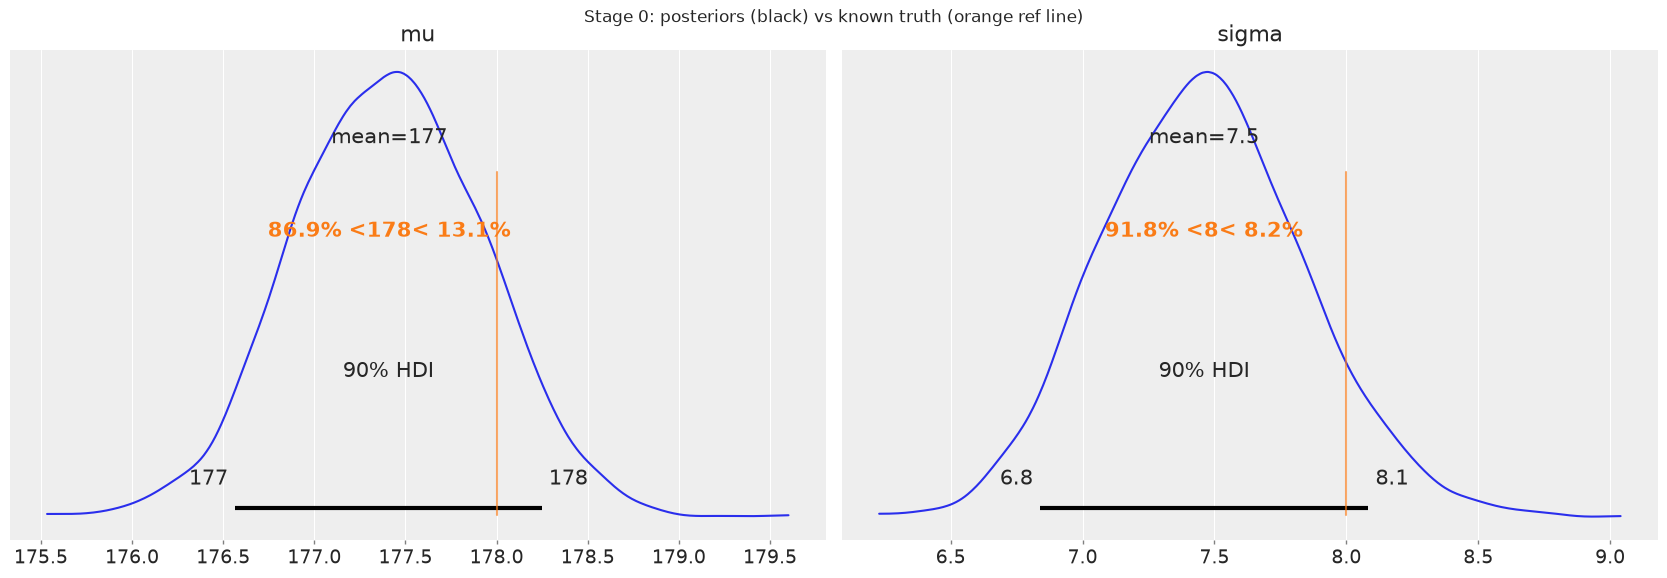

In [3]:
ax = az.plot_posterior(idata0, var_names=["mu","sigma"],
                       ref_val=[mu_true, sigma_true], hdi_prob=0.9)
plt.suptitle("Stage 0: posteriors (black) vs known truth (orange ref line)", y=1.02)
plt.show()

## Data load — self-fetch with local cache fallback

`Howell1.csv` lives in McElreath's *rethinking* repo and is **`;`-delimited** (a classic
gotcha). We fetch the raw URL, fall back to the cached `data/` copy if offline, and **filter
to adults (`age >= 18`)** — height is bimodal across children, and the single-Gaussian model
is only sensible for adults (we add weight as a predictor in P03).

In [4]:
URL = "https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/Howell1.csv"
CACHE = "data/Howell1.csv"
try:
    raw = urllib.request.urlopen(URL, timeout=30).read().decode()
    os.makedirs("data", exist_ok=True)
    with open(CACHE, "w") as f:
        f.write(raw)
    df = pd.read_csv(io.StringIO(raw), sep=";")
    print("loaded from raw URL")
except Exception as e:
    print("network failed (%s) -> cache" % type(e).__name__)
    df = pd.read_csv(CACHE, sep=";")
adults = df[df.age >= 18].reset_index(drop=True)
print("full:", df.shape, "| adults:", adults.shape)
adults.head()

loaded from raw URL
full: (544, 4) | adults: (352, 4)


,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0


### Stage 1–2 — Question & EDA

**Question:** what is the mean adult !Kung height, with honest uncertainty?  
**Target quantity:** μ (population mean height, cm) and σ (spread). **Unit:** one adult person.

n=352 | mean=154.60 cm | sd=7.73 cm | range=[136.5, 179.1]


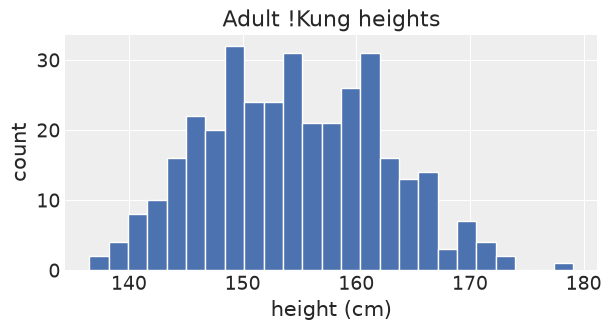

In [5]:
h = adults.height.values
print(f"n={h.size} | mean={h.mean():.2f} cm | sd={h.std():.2f} cm | range=[{h.min():.1f}, {h.max():.1f}]")
fig, ax = plt.subplots(figsize=(6,3.2))
ax.hist(h, bins=25, color="#4c72b0", edgecolor="white")
ax.set_xlabel("height (cm)"); ax.set_ylabel("count"); ax.set_title("Adult !Kung heights")
plt.show()

## Stage 3 — Model specification

$$h_i \sim \mathrm{Normal}(\mu, \sigma) \qquad \mu \sim \mathrm{Normal}(178, 20) \qquad \sigma \sim \mathrm{HalfNormal}(20)$$

- **Likelihood:** Gaussian — a symmetric continuous outcome with no covariates yet.
- **μ prior** `Normal(178, 20)`: centred on a human adult height with a wide ±40 cm range.
- **σ prior** `HalfNormal(20)`: modern weakly-informative choice for a scale parameter
  (the spec replaces the older `Uniform`/`HalfCauchy`). Positive by construction, gentle mass below ~40 cm.

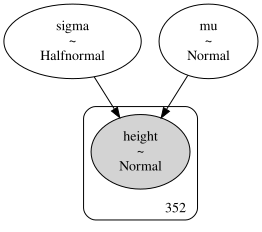

In [6]:
with pm.Model() as model:
    mu = pm.Normal("mu", 178, 20)
    sigma = pm.HalfNormal("sigma", 20)
    height = pm.Normal("height", mu, sigma, observed=h)
try:
    display(pm.model_to_graphviz(model))
except Exception as e:
    print("graphviz unavailable (%s) — DAG: mu, sigma -> height" % type(e).__name__)

## Stage 4 — Prior predictive check (**outcome scale**) · [upgraded]

The point is to check the prior over *heights in cm*, not the abstract parameters. We sample
the prior predictive and confirm essentially no negative heights and a humane plausible range.

Sampling: [height, mu, sigma]


prior-predictive heights: range [-15, 446] cm | fraction < 0: 0.000


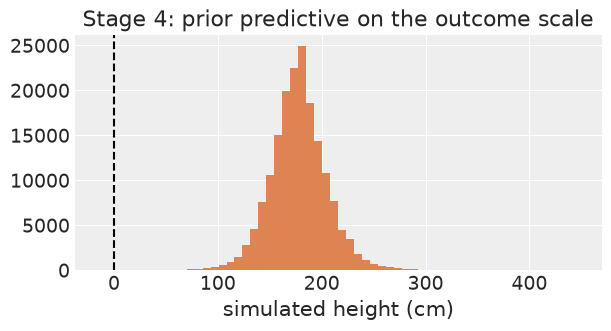

In [7]:
with model:
    prior = pm.sample_prior_predictive(samples=500, random_seed=RANDOM_SEED)
pp = prior.prior_predictive["height"].values.ravel()
print(f"prior-predictive heights: range [{pp.min():.0f}, {pp.max():.0f}] cm | fraction < 0: {(pp<0).mean():.3f}")
fig, ax = plt.subplots(figsize=(6,3.2))
ax.hist(pp, bins=60, color="#dd8452", edgecolor="none")
ax.axvline(0, color="k", ls="--"); ax.set_xlabel("simulated height (cm)")
ax.set_title("Stage 4: prior predictive on the outcome scale")
plt.show()

The prior is deliberately broad (it reaches implausibly tall values) but puts **no mass on
negative heights** and is centred on human scales — adequate for a first pass. A tighter
`σ ~ HalfNormal(10)` would remove the tallest tails; we keep the broad prior to show the data,
not the prior, drives the posterior (confirmed in Stage 10).

## Stage 5 — Fit

In [8]:
t0 = time.time()
with model:
    idata = pm.sample(1000, tune=1000, chains=4, target_accept=0.9,
                      random_seed=RANDOM_SEED, progressbar=False)
    idata.extend(pm.sample_posterior_predictive(idata, random_seed=RANDOM_SEED, progressbar=False))
    idata = pm.compute_log_likelihood(idata, progressbar=False)
print(f"sampling wall-clock: {time.time()-t0:.1f} s")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [mu, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


Sampling: [height]


sampling wall-clock: 2.3 s


## Stage 6 — Computational diagnostics (model-aware)

Continuous NUTS targets: **R̂ < 1.01**, **ESS-bulk & ESS-tail > 400**, **0 divergences**, **BFMI > 0.3**, fuzzy-caterpillar traces.

In [9]:
summ = az.summary(idata, var_names=["mu","sigma"], hdi_prob=0.94)
print(summ[["mean","sd","hdi_3%","hdi_97%","r_hat","ess_bulk","ess_tail"]])
div = int(idata.sample_stats.diverging.values.sum())
print(f"\ndivergences: {div} | BFMI per chain: {np.round(az.bfmi(idata),3)}")

          mean     sd   hdi_3%  hdi_97%  r_hat  ess_bulk  ess_tail
mu     154.606  0.421  153.808  155.389    1.0    3233.0    2471.0
sigma    7.771  0.302    7.177    8.310    1.0    3455.0    2267.0

divergences: 0 | BFMI per chain: [1.03  1.115 1.148 1.069]


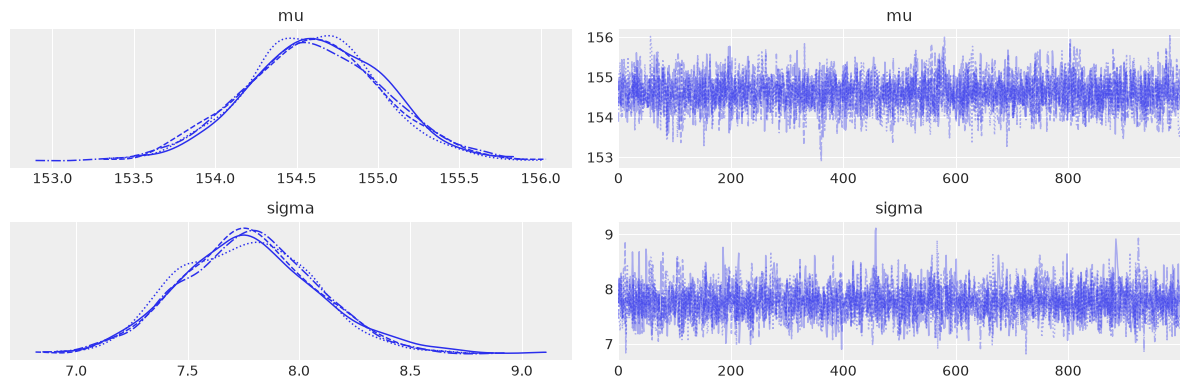

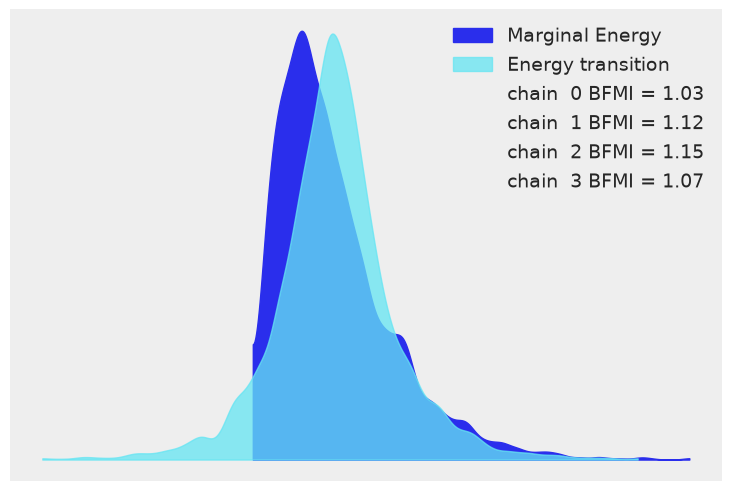

In [10]:
az.plot_trace(idata, var_names=["mu","sigma"]); plt.tight_layout(); plt.show()
az.plot_energy(idata); plt.show()

## Stage 7 — Posterior summary & interpretation (original units, cm)

Mean adult height mu = 154.6 cm  (94% HDI 153.8-155.4)
SD of heights  sigma = 7.77 cm  -> ~95% of adults within 139-170 cm


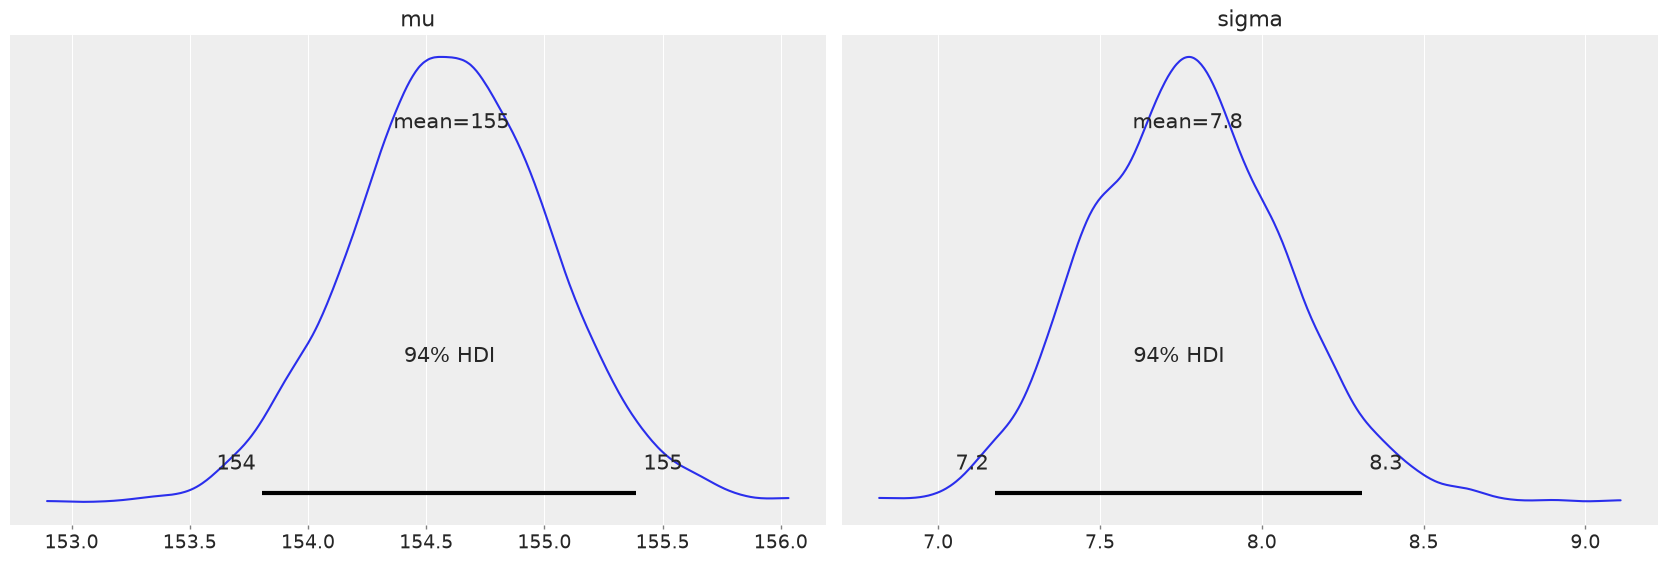

In [11]:
mu_m = idata.posterior["mu"].mean().item(); sig_m = idata.posterior["sigma"].mean().item()
mu_hdi = az.hdi(idata, var_names=["mu"], hdi_prob=0.94)["mu"].values
print(f"Mean adult height mu = {mu_m:.1f} cm  (94% HDI {mu_hdi[0]:.1f}-{mu_hdi[1]:.1f})")
print(f"SD of heights  sigma = {sig_m:.2f} cm  -> ~95% of adults within {mu_m-2*sig_m:.0f}-{mu_m+2*sig_m:.0f} cm")
az.plot_posterior(idata, var_names=["mu","sigma"], hdi_prob=0.94); plt.show()

## Stage 8 — Posterior predictive check · [required]

For a continuous outcome the informative discrepancy statistics are **mean, sd, min, max**.
A Bayesian p-value near 0.5 means the model reproduces that feature; near 0 or 1 flags
systematic misfit.

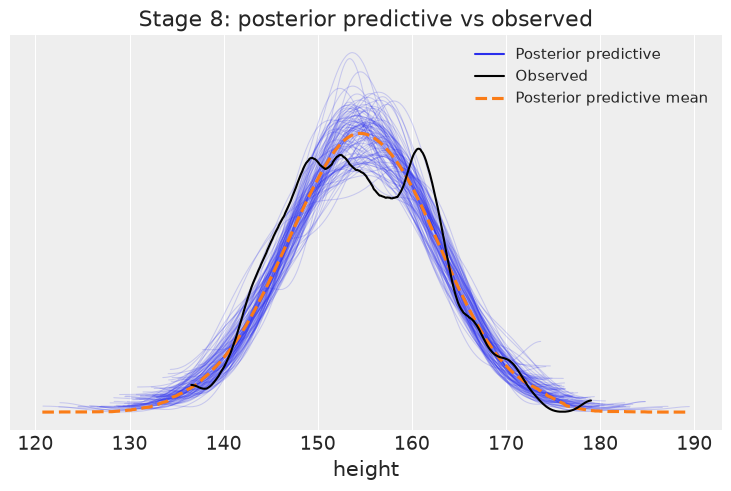

Bayesian p-values (P[T(rep) >= T(obs)]):
  mean: obs= 154.60  p=0.50
  sd  : obs=   7.73  p=0.50
  min : obs= 136.53  p=0.04
  max : obs= 179.07  p=0.25


In [12]:
az.plot_ppc(idata, num_pp_samples=100); plt.title("Stage 8: posterior predictive vs observed"); plt.show()
ppc = idata.posterior_predictive["height"].values.reshape(-1, h.size)
print("Bayesian p-values (P[T(rep) >= T(obs)]):")
for name, fn in [("mean",np.mean),("sd",np.std),("min",np.min),("max",np.max)]:
    print(f"  {name:4s}: obs={fn(h):7.2f}  p={(fn(ppc,axis=1)>=fn(h)).mean():.2f}")

`mean` and `sd` sit at p≈0.5 — the Gaussian nails the centre and spread. `min` is the only
mild flag (p≈0.04): real heights have a slightly heavier *short* tail than a symmetric Gaussian
predicts. That is the systematic misfit that *motivates the next model* (Stage 11).

## Stage 9 — Model comparison: Normal vs Student-t (robust)

A meaningful expansion is to swap the Gaussian for a **Student-t** likelihood, which tolerates
outliers via the degrees-of-freedom ν. We compare with **PSIS-LOO** (`az.compare`, stacking
weights by default) and read `elpd_diff` against its SE (`dse`).

In [13]:
with pm.Model() as model_t:
    mu = pm.Normal("mu", 178, 20)
    sigma = pm.HalfNormal("sigma", 20)
    nu = pm.Gamma("nu", alpha=2, beta=0.1)
    pm.StudentT("height", nu=nu, mu=mu, sigma=sigma, observed=h)
    idata_t = pm.sample(1000, tune=1000, chains=4, target_accept=0.95, random_seed=RANDOM_SEED,
                        progressbar=False, idata_kwargs={"log_likelihood": True})
cmp = az.compare({"normal": idata, "student_t": idata_t})
print(cmp[["rank","elpd_loo","elpd_diff","dse","weight"]])
khat = az.loo(idata, pointwise=True).pareto_k.values
thr = min(1 - 1/np.log10(idata.posterior.draw.size*idata.posterior.chain.size), 0.7)
print(f"\nPareto k-hat: max={khat.max():.2f} | threshold min(1-1/log10(S),0.7)={thr:.2f} | all good: {(khat<thr).all()}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [mu, sigma, nu]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


           rank     elpd_loo  elpd_diff       dse        weight
normal        0 -1221.366004   0.000000  0.000000  1.000000e+00
student_t     1 -1222.910857   1.544854  0.472651  5.551115e-17



Pareto k-hat: max=0.10 | threshold min(1-1/log10(S),0.7)=0.70 | all good: True


The Normal is preferred (top rank), and the gap to Student-t is small relative to its SE —
with no real outliers the extra ν parameter buys nothing. All Pareto-k̂ are below the
sample-size-aware threshold, so the LOO estimate is reliable.

## Stage 10 — Power-scaling prior sensitivity

We power-scale the **prior** by α and importance-reweight the existing posterior draws
(weight ∝ prior^{α−1}). If conclusions barely move as α ranges over 0.8–1.25, the prior is
not driving them — the data dominates.

In [14]:
post = az.extract(idata)
mu_d, sig_d = post["mu"].values, post["sigma"].values
logprior = st.norm.logpdf(mu_d,178,20) + st.halfnorm.logpdf(sig_d, scale=20)
print("alpha   E[mu] (cm)   E[sigma] (cm)")
for a in [0.8, 1.0, 1.25]:
    w = np.exp((a-1)*logprior); w /= w.sum()
    print(f" {a:4.2f}   {np.sum(w*mu_d):8.3f}     {np.sum(w*sig_d):8.3f}")

alpha   E[mu] (cm)   E[sigma] (cm)
 0.80    154.604        7.771
 1.00    154.606        7.771
 1.25    154.609        7.770


μ moves by < 0.01 cm across the full α sweep — the conclusion is **robust** to the prior.

## Stage 11–12 — Expansion, decision & communication

**Next model (Stage 11):** the only PPC flag was the short-height tail. The concrete expansion
is **P03: height ~ weight** — a linear mean removes the structure the constant-μ model leaves in
the residuals. (P03 is exactly that model.)

**Decision (Stage 12) — headline:** *the mean height of !Kung San adults is **154.6 cm**
(94% HDI 153.8–155.4), with an individual-to-individual standard deviation of **7.8 cm**.* The
estimate is tightly determined and insensitive to the prior; the only caveat is a mildly
heavier short tail than a single Gaussian implies.

In [15]:
os.makedirs("report", exist_ok=True)
idata.to_netcdf("report/P01_idata.nc")
print("saved report/P01_idata.nc")

saved report/P01_idata.nc


## Exercises (your turn)
1. **Tighten the prior.** Re-run Stage 4 with `sigma ~ HalfNormal(10)` and `mu ~ Normal(178, 10)`.
   Does the prior predictive look more reasonable? Does the *posterior* change? (Tie back to Stage 10.)
2. **Children included.** Drop the `age >= 18` filter and re-fit. Use the PPC to show why a single
   Gaussian is now wrong, and propose the fix.
3. **Predictive interval.** Compute the 90% *posterior predictive* interval for a single new adult's
   height and explain why it is much wider than the 90% HDI for μ.